# Demo 5 — Paint the pixels

_Section 5: Object Segmentation._

Segmentation answers: **"Which exact pixels belong to each object?"** Instead of a blunt box, we get a **mask** — a per-pixel label. We'll run segmentation, then use the mask to **blur or replace the background**, keeping only the subject's pixels.

In [1]:
import warnings

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import supervision as sv
from rfdetr import RFDETRSegSmall
from rfdetr.assets.coco_classes import COCO_CLASSES

warnings.filterwarnings("ignore")

IMG_PATH = "demo.jpg"  # the shared image used across all demos

objc[71136]: Class AVFFrameReceiver is implemented in both /Users/mahyoubm/Documents/adhoc/cv-intro/.venv/lib/python3.12/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x10c5203a8) and /Users/mahyoubm/Documents/adhoc/cv-intro/.venv/lib/python3.12/site-packages/av/.dylibs/libavdevice.62.3.102.dylib (0x1221483a8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[71136]: Class AVFAudioReceiver is implemented in both /Users/mahyoubm/Documents/adhoc/cv-intro/.venv/lib/python3.12/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x10c5203f8) and /Users/mahyoubm/Documents/adhoc/cv-intro/.venv/lib/python3.12/site-packages/av/.dylibs/libavdevice.62.3.102.dylib (0x1221483f8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
/Users/mahyoubm/Documents/adhoc/cv-intro/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. P

## 1. Load the image and the segmentation model

**RF-DETR (seg)** returns everything detection did — box, class, confidence — **plus a mask** for each object: a True/False grid the same size as the image.

In [2]:
bgr = cv2.imread(IMG_PATH)                    # OpenCV loads as BGR
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)    # -> RGB
image = Image.fromarray(rgb)                  # RF-DETR takes a PIL image

model = RFDETRSegSmall()
print("Loaded RF-DETR (seg, small).")

[2026-08-15 23:59:30] [INFO] rf-detr - File /Users/mahyoubm/.roboflow/models/rf-detr-seg-small.pt already exists with correct MD5 hash.


[2026-08-15 23:59:30] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-08-15 23:59:30] [WARNING] rf-detr - Using patch size 12 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-08-15 23:59:30] [INFO] rf-detr - File /Users/mahyoubm/.roboflow/models/rf-detr-seg-small.pt already exists with correct MD5 hash.
Loaded RF-DETR (seg, small).


## 2. Run segmentation

Each detection now carries a **mask**. The masks stack into an array of shape `(num_objects, height, width)`.

In [3]:
detections = model.predict(image, threshold=0.5)

print(f"Found {len(detections)} objects.")
print("masks array shape:", detections.mask.shape, "(objects, height, width)")
print("each mask is:", detections.mask.dtype, "-> True = this pixel belongs to the object\n")
for name, m in zip((COCO_CLASSES[c] for c in detections.class_id), detections.mask):
    print(f"  {name:12s} covers {100 * m.mean():4.1f}% of the pixels")

[2026-08-15 23:59:30] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. For full GPU throughput (e.g. ~8x on T4 via FP16 Tensor Cores), call model.inference(dtype=torch.float16).


Found 5 objects.
masks array shape: (5, 360, 480) (objects, height, width)
each mask is: bool -> True = this pixel belongs to the object

  person       covers 12.9% of the pixels
  couch        covers 17.7% of the pixels
  cat          covers 12.8% of the pixels
  sports ball  covers  1.6% of the pixels
  chair        covers  5.6% of the pixels


## 3. See the masks

**supervision** paints each object's mask in its own color — every pixel is now labelled.

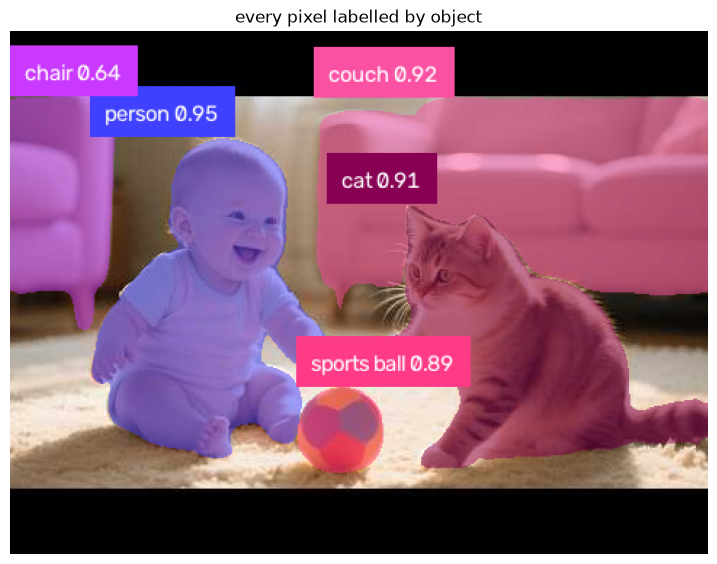

In [4]:
mask_annotator = sv.MaskAnnotator()
label_annotator = sv.LabelAnnotator()

labels = [
    f"{COCO_CLASSES[c]} {conf:.2f}"
    for c, conf in zip(detections.class_id, detections.confidence)
]
overlay = mask_annotator.annotate(rgb.copy(), detections)
overlay = label_annotator.annotate(overlay, detections, labels)

plt.figure(figsize=(9, 7))
plt.imshow(overlay)
plt.axis("off")
plt.title("every pixel labelled by object")
plt.show()

## 4. Box vs. mask

Take a single object (the cat). A **box** is a rectangle that grabs background corners; a **mask** is exactly the cat's pixels.

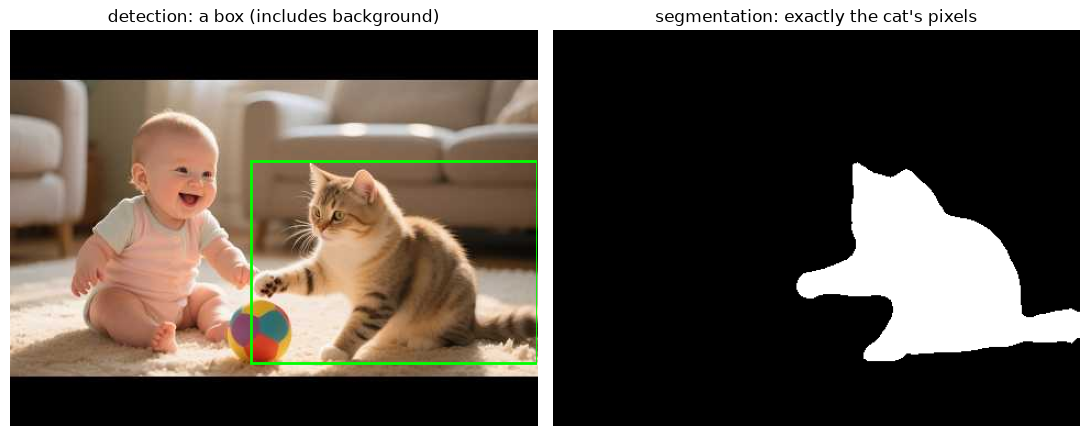

In [5]:
# find the cat detection
cat_idx = next(i for i, c in enumerate(detections.class_id)
               if COCO_CLASSES[c] == "cat")
cat_mask = detections.mask[cat_idx]
x1, y1, x2, y2 = detections.xyxy[cat_idx]

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
ax[0].imshow(rgb)
ax[0].add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1,
                              edgecolor="lime", facecolor="none", lw=2))
ax[0].axis("off")
ax[0].set_title("detection: a box (includes background)")

ax[1].imshow(cat_mask, cmap="gray")
ax[1].axis("off")
ax[1].set_title("segmentation: exactly the cat's pixels")
plt.tight_layout()
plt.show()

## 5. Use the mask: blur the background

Combine the masks of the things we care about — the **baby, cat, and ball** — into one "subject" mask, then keep those pixels sharp and blur everything else. This is exactly how phone "portrait mode" works.

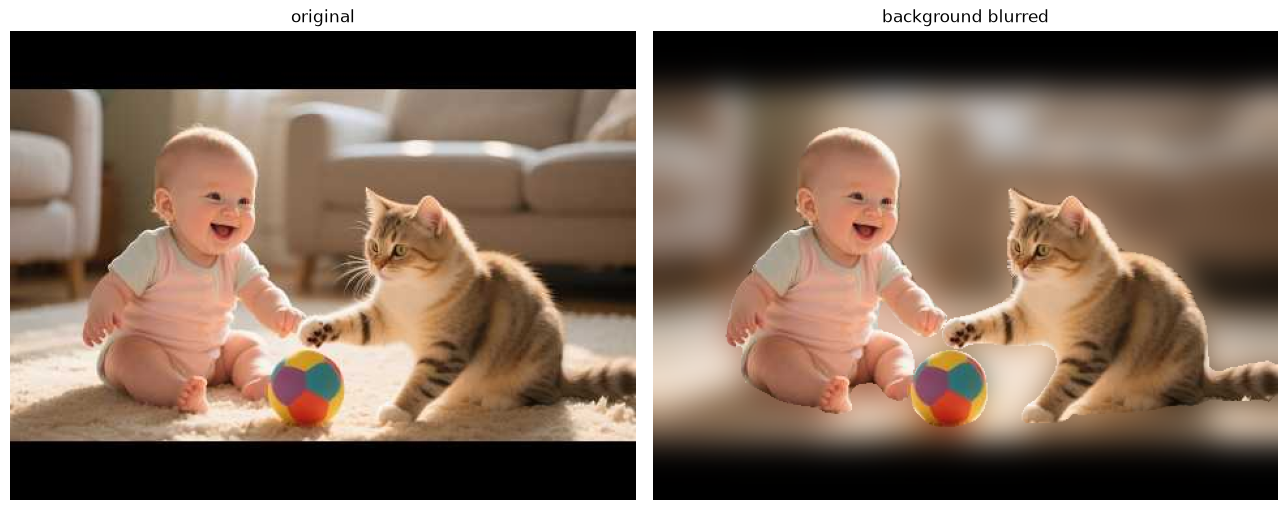

In [6]:
SUBJECTS = {"person", "cat", "sports ball"}
keep = np.array([COCO_CLASSES[c] in SUBJECTS for c in detections.class_id])
subject_mask = np.any(detections.mask[keep], axis=0)  # (H, W) bool

blurred = cv2.GaussianBlur(rgb, (0, 0), sigmaX=12)
portrait = np.where(subject_mask[..., None], rgb, blurred)  # sharp subject, blurry rest

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].imshow(rgb);      ax[0].axis("off"); ax[0].set_title("original")
ax[1].imshow(portrait); ax[1].axis("off"); ax[1].set_title("background blurred")
plt.tight_layout()
plt.show()

## 6. Or replace the background entirely

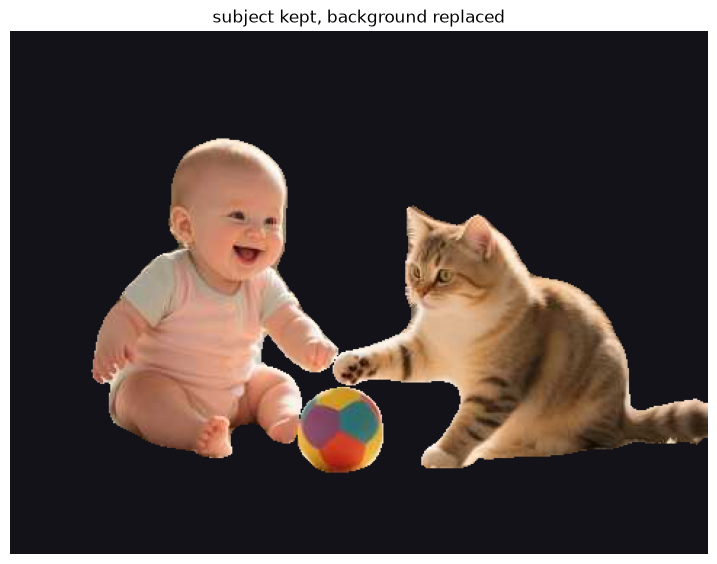

In [7]:
background = np.full_like(rgb, (18, 18, 24))          # any color (or another image)
cutout = np.where(subject_mask[..., None], rgb, background)

plt.figure(figsize=(9, 7))
plt.imshow(cutout)
plt.axis("off")
plt.title("subject kept, background replaced")
plt.show()

## Takeaway

A mask labels **every pixel** as "belongs to this object" or not — precise enough to cut out a subject, blur a background, outline a tumor, or tell a robot exactly where to grab.

We now know **what**, **where**, and the **exact shape**. The last question is the hardest: **what is actually going on** in the scene? → **image understanding**.